<a href="https://colab.research.google.com/github/JSEFERINO/MIS-CURSOS-2026/blob/main/Sustentaciones_Julio_Hurtado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Formato para Trabajar en Colab 2026**
# **Teoria de Probabilidad**
## **JULIO SEFERINO HURTADO MARQUEZ**
> Email: juliohurtado210307@gmail.com


# **Librerias para Trabar en R**

In [13]:
# @title **Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

<a name="inicio"></a>


## **1.** [Ejemplo: Simulación de lanzar una moneda al aire y observar la cara de la moneda que mira hacia arriba al caer](#T1)
## **2.** [Experimento Aleatorio - Lanzamiento de un dado (6 caras)](#T2)

## **3.** [Experimento: Lanzamiento de una moneda](#T3)

## **4.** [Ejemplo 1: Lanzamiento de un dado justo usando R](#T4)

## **5.** [Ejemplo: Preferencias de helado](#T5)

## **6.** [](#T6)

## **7.** [](#T7)


## **8.** [](#T8)

## **9.** [](#T9)


## **10.** [](#T10)

## **11.** [](#T11)

## **12.** [](#T12)

## **13.** [](#T13)

## **14.** [](#T14)

## **15.** [](#T15)

## **16.** [](#T16)

## **17.** [](#T17)


## **18.** [](#T18)

## **19.** [](#T19)


## **20.** [](#T20)

## **21.** [](#T21)

## **22.** [](#T22)

## **23.** [](#T23)

## **24.** [](#T24)

## **25.** [](#T25)

## **26.** [](#T26)

## **27.** [](#T27)


## **28.** [](#T28)

## **29.** [](#T29)


## **30.** [](#T30)

## **31.** [](#T31)



[ULTIMO](#ULTIMO)

[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **1. Ejemplo: Simulación de lanzar una moneda al aire y observar la cara de la moneda que mira hacia arriba al caer**


{'CARA': 0, 'SELLO': 0}


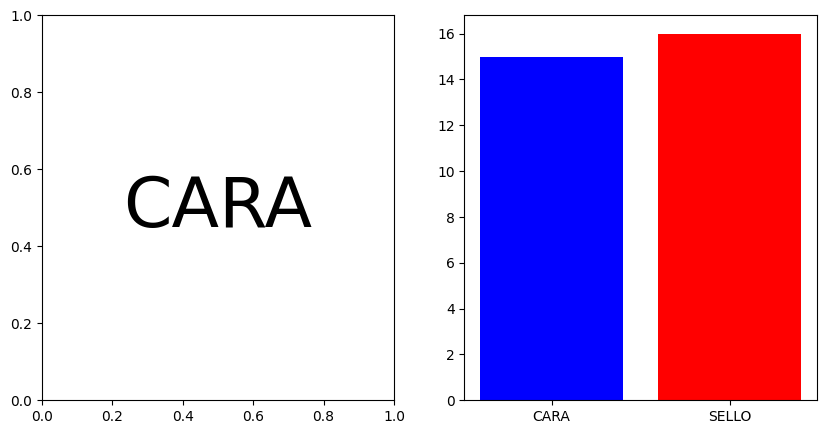

In [ ]:
# @title **Lanzamiento de una moneda**
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np

# Función para lanzar la moneda
def lanzar_moneda():
    return np.random.choice(['CARA', 'SELLO'])

# Inicialización de variables para contar los resultados
resultados = {'CARA': 0, 'SELLO': 0}

# Función para actualizar los resultados y el gráfico en cada fotograma de la animación
def actualizar(i):
    resultado = lanzar_moneda()
    resultados[resultado] += 1
    ejes[0].clear()
    ejes[0].text(0.5, 0.5, resultado, fontsize=50, ha='center', va='center')
    ejes[1].clear()
    ejes[1].bar(resultados.keys(), resultados.values(), color=['blue', 'red'])

# Configuración inicial del gráfico
fig, ejes = plt.subplots(1, 2, figsize=(10, 5))

# Configuración de la animación
ani = animation.FuncAnimation(fig, actualizar, frames=29, interval=500, repeat=False)
print(resultados)
# Muestra la animación en el notebook
HTML(ani.to_html5_video())

In [ ]:
# @title **Lanzamiento de una moneda usando R**
# Cargar librerías necesarias
%%R
# Instalar y cargar librerías si no están ya instaladas
if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2", repos = "http://cran.us.r-project.org")
}
library(ggplot2)

if (!requireNamespace("gganimate", quietly = TRUE)) {
  install.packages("gganimate", repos = "http://cran.us.r-project.org")
}
library(gganimate)

if (!requireNamespace("dplyr", quietly = TRUE)) {
  install.packages("dplyr", repos = "http://cran.us.r-project.org")
}
library(dplyr)

if (!requireNamespace("tidyr", quietly = TRUE)) {
  install.packages("tidyr", repos = "http://cran.us.r-project.org")
}
library(tidyr)

if (!requireNamespace("gifski", quietly = TRUE)) {
  install.packages("gifski", repos = "http://cran.us.r-project.org")
}
library(gifski)

if (!requireNamespace("png", quietly = TRUE)) {
  install.packages("png", repos = "http://cran.us.r-project.org")
}
library(png)

# Función para lanzar la moneda
lanzar_moneda <- function() {
  return(sample(c("CARA", "SELLO"), 1))
}

# Inicialización de variables para contar los resultados
resultados <- c(CARA = 0, SELLO = 0)

# DataFrame para almacenar los resultados de cada lanzamiento
lanzamientos <- data.frame()

# Realizar 30 lanzamientos
set.seed(123)  # Para reproducibilidad (opcional)
for (i in 1:30) {
  resultado <- lanzar_moneda()
  resultados[resultado] <- resultados[resultado] + 1

  lanzamientos <- rbind(lanzamientos, data.frame(
    lanzamiento = i,
    resultado = resultado,
    CARA_acum = resultados["CARA"],
    SELLO_acum = resultados["SELLO"]
  ))
}

# Transformar datos para ggplot2 (formato largo)
lanzamientos_long <- lanzamientos %>%
  pivot_longer(cols = c(CARA_acum, SELLO_acum),
               names_to = "moneda",
               values_to = "frecuencia") %>%
  mutate(moneda = gsub("_acum", "", moneda))

# Crear datos para el texto del resultado actual
texto_resultado <- lanzamientos %>%
  select(lanzamiento, resultado)

# Gráfico principal mejorado
p <- ggplot(lanzamientos_long, aes(x = moneda, y = frecuencia, fill = moneda)) +
  geom_bar(stat = "identity", position = position_dodge(), alpha = 0.8) +
  geom_text(aes(label = frecuencia), vjust = -0.5, size = 5, position = position_dodge(0.9)) +
  scale_fill_manual(values = c("CARA" = "#3498db", "SELLO" = "#e74c3c")) +
  scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    plot.subtitle = element_text(hjust = 0.5, size = 12),
    legend.position = "none",
    panel.grid.minor = element_blank()
  ) +
  labs(title = "Lanzamiento de moneda",
       subtitle = paste("Lanzamiento: {closest_state}"),
       x = "Resultado",
       y = "Frecuencia acumulada") +
  transition_states(lanzamiento, transition_length = 2, state_length = 1) +
  ease_aes('cubic-in-out') +
  enter_grow() +
  exit_fade() +
  shadow_mark(alpha = 0.3, size = 0.5)

# Animar y guardar como GIF
animacion <- animate(p,
                     nframes = 30,
                     fps = 3,
                     width = 700,
                     height = 500,
                     renderer = gifski_renderer("lanzamiento_moneda.gif"),
                     end_pause = 10)

# Mostrar información en consola
cat("\n", rep("=", 50), "\n")
cat("        RESULTADOS DEL LANZAMIENTO DE MONEDA\n")
cat(rep("=", 50), "\n\n")

for (i in 1:nrow(lanzamientos)) {
  cat(sprintf("Lanzamiento %2d: %s",
              lanzamientos$lanzamiento[i],
              lanzamientos$resultado[i]))
  cat(sprintf("   | Acumulado: CARA=%2d, SELLO=%2d\n",
              lanzamientos$CARA_acum[i],
              lanzamientos$SELLO_acum[i]))
  Sys.sleep(0.3)
}

cat("\n", rep("-", 50), "\n")
cat("RESUMEN FINAL:\n")
cat(sprintf("  • CARA:  %2d veces (%.1f%%)\n",
            resultados["CARA"],
            resultados["CARA"]/30*100))
cat(sprintf("  • SELLO: %2d veces (%.1f%%)\n",
            resultados["SELLO"],
            resultados["SELLO"]/30*100))
cat(rep("=", 50), "\n\n")

# Función interactiva para lanzar moneda manualmente
lanzar_interactivo <- function() {
  cat("Presiona Enter para lanzar la moneda (o 'q' para salir):\n")
  contador <- c(CARA = 0, SELLO = 0)
  n_lanzamientos <- 0

  while(TRUE) {
    entrada <- readline(prompt = "> ")
    if(tolower(entrada) == 'q') break

    resultado <- lanzar_moneda()
    contador[resultado] <- contador[resultado] + 1
    n_lanzamientos <- n_lanzamientos + 1

    cat(sprintf("\n✨ Lanzamiento %d: %s ✨\n", n_lanzamientos, resultado))
    cat(sprintf("📊 Historial: CARA=%d, SELLO=%d\n", contador["CARA"], contador["SELLO"]))

    # Gráfico rápido con ASCII
    total <- contador["CARA"] + contador["SELLO"]
    if(total > 0) {
      barra_cara <- paste(rep("█", round(contador["CARA"]/total*30)), collapse = "")
      barra_sello <- paste(rep("█", round(contador["SELLO"]/total*30)), collapse = "")
      cat(sprintf("  CARA:  [%-30s] %d\n", barra_cara, contador["CARA"]))
      cat(sprintf("  SELLO: [%-30s] %d\n", barra_sello, contador["SELLO"]))
    }
    cat("\n")
  }

  cat("\n🎯 Resultado final:\n")
  cat(sprintf("  CARA:  %d (%.1f%%)\n", contador["CARA"], contador["CARA"]/n_lanzamientos*100))
  cat(sprintf("  SELLO: %d (%.1f%%)\n", contador["SELLO"], contador["SELLO"]/n_lanzamientos*100))
}

# Mostrar el GIF (si está en RStudio)
if(interactive()) {
  cat("\n🎬 Animación guardada como 'lanzamiento_moneda.gif'\n")
  cat("Para ver la animación, ejecuta:\n")
  cat("  browseURL('lanzamiento_moneda.gif')\n\n")

  # Opción interactiva
  cat("¿Quieres lanzar la moneda interactivamente? (s/n): ")
  respuesta <- readline()
  if(tolower(respuesta) == 's') {
    lanzar_interactivo()
  }
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘classInt’, ‘s2’, ‘units’, ‘sf’, ‘lpSolve’, ‘transformr’, ‘tweenr’

trying URL 'http://cran.us.r-project.org/src/contrib/proxy_0.4-29.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/e1071_1.7-17.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/wk_0.9.5.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/classInt_0.4-11.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/s2_1.1.11.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/units_1.0-1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/sf_1.1-1.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/lpSolve_5.6.23.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/transformr_0.1.5.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/tweenr_2.0.3.tar.gz'
trying URL 'http://cran.us.r-project.org/src/contrib/gga

RInterpreterError: Failed to parse and evaluate line '# Instalar y cargar librerías si no están ya instaladas\nif (!requireNamespace("ggplot2", quietly = TRUE)) {\n  install.packages("ggplot2", repos = "http://cran.us.r-project.org")\n}\nlibrary(ggplot2)\n\nif (!requireNamespace("gganimate", quietly = TRUE)) {\n  install.packages("gganimate", repos = "http://cran.us.r-project.org")\n}\nlibrary(gganimate)\n\nif (!requireNamespace("dplyr", quietly = TRUE)) {\n  install.packages("dplyr", repos = "http://cran.us.r-project.org")\n}\nlibrary(dplyr)\n\nif (!requireNamespace("tidyr", quietly = TRUE)) {\n  install.packages("tidyr", repos = "http://cran.us.r-project.org")\n}\nlibrary(tidyr)\n\nif (!requireNamespace("gifski", quietly = TRUE)) {\n  install.packages("gifski", repos = "http://cran.us.r-project.org")\n}\nlibrary(gifski)\n\nif (!requireNamespace("png", quietly = TRUE)) {\n  install.packages("png", repos = "http://cran.us.r-project.org")\n}\nlibrary(png)\n\n# Función para lanzar la mon

[⬆️ Volver al inicio](#inicio)

<a name="T2"></a>
## **2. Experimento Aleatorio - Lanzamiento de un dado (6 caras)**


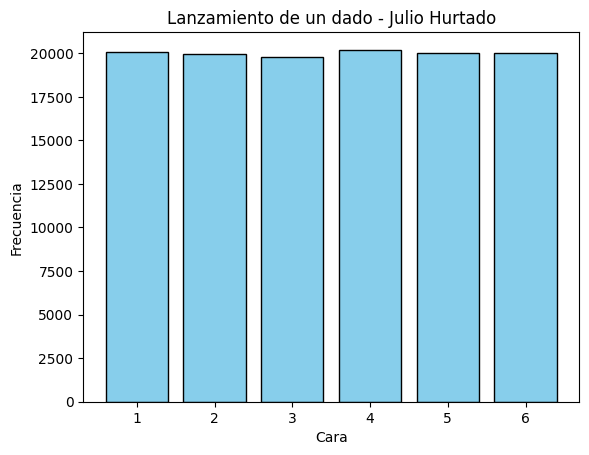

In [5]:
# @title **Lanzamiento de un dado**
import numpy as np
import matplotlib.pyplot as plt

# Simulación
n = 120000
resultados = np.random.randint(1, 7, size=n)

# Gráfico
plt.hist(resultados, bins=np.arange(0.5, 7.5, 1), rwidth=0.8, color="skyblue", edgecolor="black")
plt.xticks(range(1, 7))
plt.title("Lanzamiento de un dado - Julio Hurtado")
plt.xlabel("Cara")
plt.ylabel("Frecuencia")
plt.show()

✅ GIF guardado como 'dado_animacion.gif'


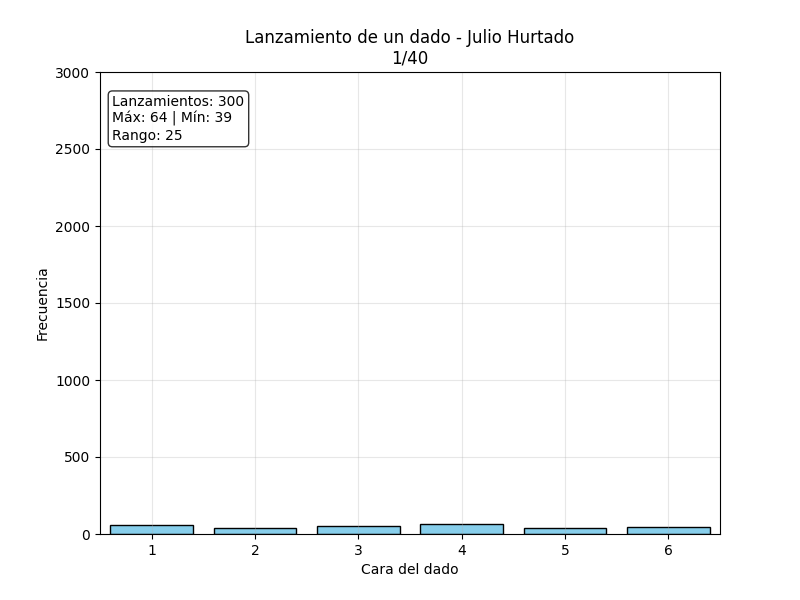

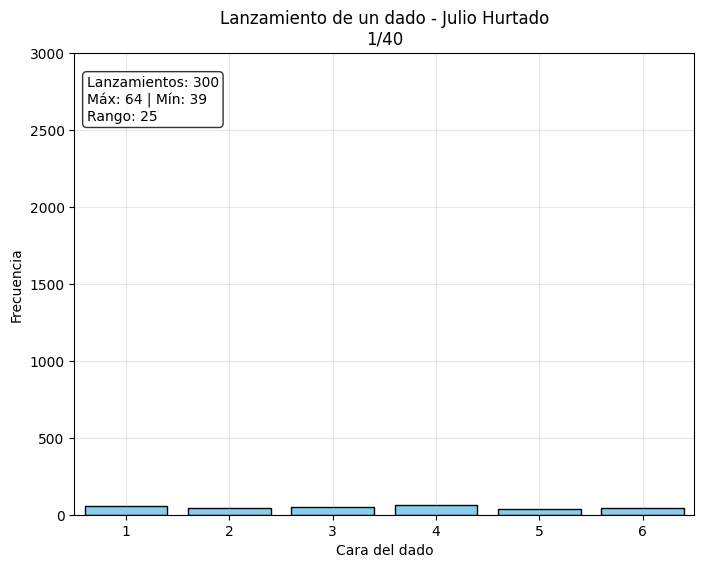

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Configuración de la animación
n_total = 12000
intervalo = 50  # milisegundos entre frames
frames_guardar = 40  # número de frames en el GIF

# Pre-generamos todos los lanzamientos
np.random.seed(42)  # para reproducibilidad
todos_resultados = np.random.randint(1, 7, size=n_total)

# Configuración de la figura
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0.5, 6.5)
ax.set_ylim(0, 450)
ax.set_xticks(range(1, 7))
ax.set_xlabel("Cara del dado")
ax.set_ylabel("Frecuencia")
ax.set_title("Evolución del lanzamiento de un dado\nJulio Hurtado")
ax.grid(True, alpha=0.3)

# Inicializar el histograma
n, bins, patches = ax.hist([], bins=np.arange(0.5, 7.5, 1),
                           rwidth=0.8, color="skyblue", edgecolor="black")

# Texto para mostrar el número de lanzamientos
texto_lanzamientos = ax.text(0.02, 0.95, '', transform=ax.transAxes,
                             fontsize=12, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

def update(frame):
    """Actualiza el histograma para cada frame"""
    # Número de lanzamientos para este frame
    n_lanzamientos = int((frame + 1) * n_total / frames_guardar)

    # Obtener los resultados hasta este momento
    resultados_actuales = todos_resultados[:n_lanzamientos]

    # Actualizar el histograma
    ax.clear()
    ax.hist(resultados_actuales, bins=np.arange(0.5, 7.5, 1),
            rwidth=0.8, color="skyblue", edgecolor="black")
    ax.set_xlim(0.5, 6.5)
    ax.set_ylim(0, 3000)
    ax.set_xticks(range(1, 7))
    ax.set_xlabel("Cara del dado")
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Lanzamiento de un dado - Julio Hurtado\n{frame+1}/{frames_guardar}")
    ax.grid(True, alpha=0.3)

    # Mostrar estadísticas
    if n_lanzamientos > 0:
        frecuencias = [np.sum(resultados_actuales == i) for i in range(1, 7)]
        max_freq = max(frecuencias)
        min_freq = min(frecuencias)
        texto = f"Lanzamientos: {n_lanzamientos}\n"
        texto += f"Máx: {max_freq} | Mín: {min_freq}\n"
        texto += f"Rango: {max_freq - min_freq}"
        ax.text(0.02, 0.95, texto, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return patches

# Crear la animación
anim = FuncAnimation(fig, update, frames=frames_guardar,
                    interval=intervalo, repeat=True)

# Guardar como GIF
anim.save('dado_animacion.gif', writer=PillowWriter(fps=20))
print("✅ GIF guardado como 'dado_animacion.gif'")

# Mostrar la animación (si estás en Jupyter notebook)
from IPython.display import Image
Image(filename='dado_animacion.gif')

[⬆️ Volver al inicio](#inicio)

<a name="T3"></a>
## **3. Experimento: Lanzamiento de una moneda**


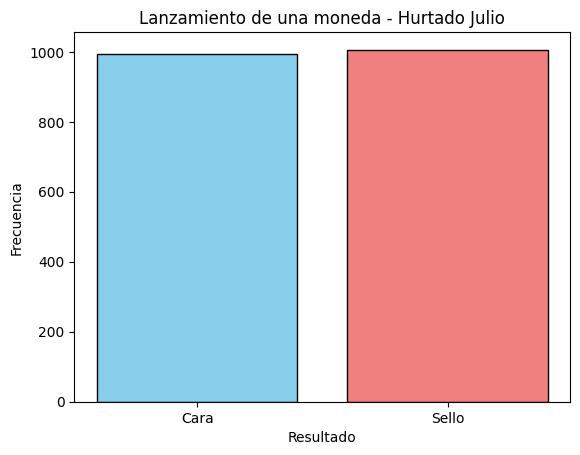

In [11]:
resultados = np.random.choice(["Cara", "Sello"], size=2000)

# Count the occurrences of each outcome
counts = np.unique(resultados, return_counts=True)
outcomes = counts[0]
frequencies = counts[1]

# Create a bar plot
plt.bar(outcomes, frequencies, color=["skyblue", "lightcoral"], edgecolor="black")
plt.title("Lanzamiento de una moneda - Hurtado Julio")
plt.xlabel("Resultado")
plt.ylabel("Frecuencia")
plt.show()

Generando animación...
✅ GIF guardado como 'moneda_animacion.gif'

📊 Estadísticas finales:
Total lanzamientos: 2000
Cara: 1016 veces
Sello: 984 veces
Diferencia: 32


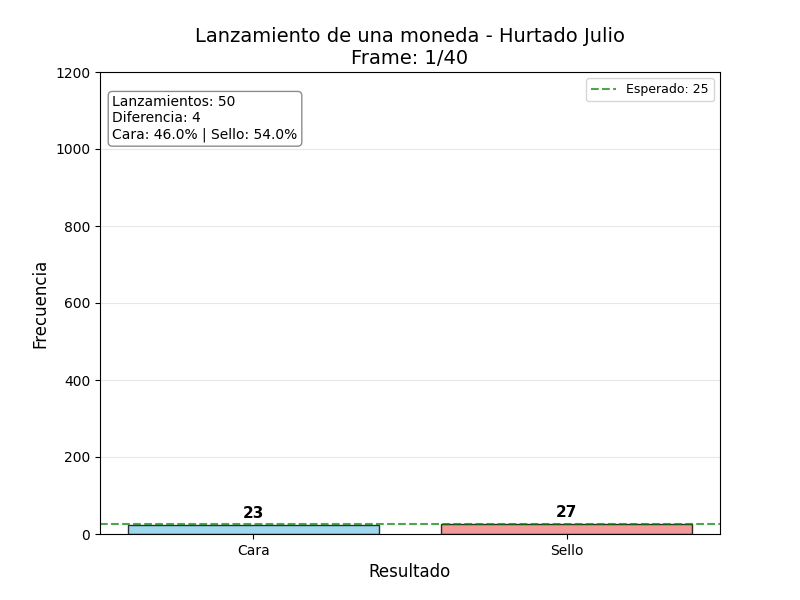

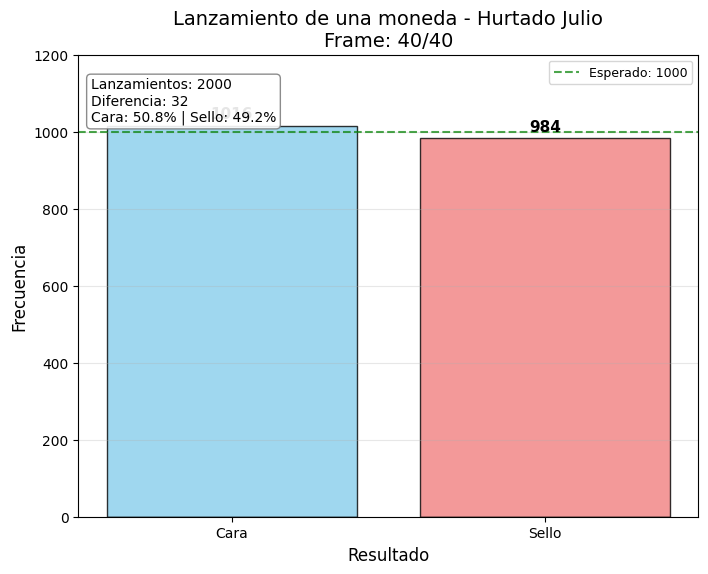

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Configuración de la animación
n_total = 2000
intervalo = 50  # milisegundos entre frames
frames_guardar = 40  # número de frames en el GIF

# Pre-generamos todos los lanzamientos
np.random.seed(42)  # para reproducibilidad
todos_resultados = np.random.choice(["Cara", "Sello"], size=n_total)

# Configuración de la figura
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_ylim(0, 1200)
ax.set_ylabel("Frecuencia")
ax.set_title("Evolución del lanzamiento de una moneda\nHurtado Julio")
ax.grid(True, alpha=0.3, axis='y')

# Colores para Cara y Sello
colores = ["skyblue", "lightcoral"]

# Función para inicializar
def init():
    ax.bar(["Cara", "Sello"], [0, 0], color=colores, edgecolor="black")
    ax.set_xlabel("Resultado")
    ax.set_ylabel("Frecuencia")
    return []

# Función de actualización para cada frame
def update(frame):
    """Actualiza el gráfico de barras para cada frame"""
    # Número de lanzamientos para este frame
    n_lanzamientos = int((frame + 1) * n_total / frames_guardar)

    # Obtener los resultados hasta este momento
    resultados_actuales = todos_resultados[:n_lanzamientos]

    # Limpiar el eje
    ax.clear()

    # Calcular frecuencias
    conteos = {outcome: np.sum(resultados_actuales == outcome) for outcome in ["Cara", "Sello"]}

    # Crear gráfico de barras
    barras = ax.bar(conteos.keys(), conteos.values(),
                    color=colores, edgecolor="black", alpha=0.8)

    # Configurar el gráfico
    ax.set_ylim(0, max(1200, max(conteos.values()) * 1.1))
    ax.set_xlabel("Resultado", fontsize=12)
    ax.set_ylabel("Frecuencia", fontsize=12)
    ax.set_title(f"Lanzamiento de una moneda - Hurtado Julio\nFrame: {frame+1}/{frames_guardar}", fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')

    # Agregar valores sobre las barras
    for i, (outcome, freq) in enumerate(conteos.items()):
        ax.text(i, freq + 10, str(freq), ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Mostrar estadísticas en el gráfico
    if n_lanzamientos > 0:
        diferencia = abs(conteos["Cara"] - conteos["Sello"])
        porcentaje_cara = (conteos["Cara"] / n_lanzamientos) * 100
        porcentaje_sello = (conteos["Sello"] / n_lanzamientos) * 100

        texto = f"Lanzamientos: {n_lanzamientos}\n"
        texto += f"Diferencia: {diferencia}\n"
        texto += f"Cara: {porcentaje_cara:.1f}% | Sello: {porcentaje_sello:.1f}%"

        ax.text(0.02, 0.95, texto, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Mostrar línea del valor esperado (1000 para 2000 lanzamientos)
    if n_lanzamientos > 0:
        esperado = n_lanzamientos / 2
        ax.axhline(y=esperado, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Esperado: {esperado:.0f}')
        ax.legend(loc='upper right', fontsize=9)

    return barras

# Crear la animación
print("Generando animación...")
anim = FuncAnimation(fig, update, frames=frames_guardar,
                    init_func=init, interval=intervalo, repeat=True)

# Guardar como GIF
anim.save('moneda_animacion.gif', writer=PillowWriter(fps=20))
print("✅ GIF guardado como 'moneda_animacion.gif'")

# Mostrar estadísticas finales
print("\n📊 Estadísticas finales:")
print(f"Total lanzamientos: {n_total}")
print(f"Cara: {np.sum(todos_resultados == 'Cara')} veces")
print(f"Sello: {np.sum(todos_resultados == 'Sello')} veces")
print(f"Diferencia: {abs(np.sum(todos_resultados == 'Cara') - np.sum(todos_resultados == 'Sello'))}")

# Si estás en Jupyter notebook, puedes mostrar el GIF con:
from IPython.display import Image
Image(filename='moneda_animacion.gif')

[⬆️ Volver al inicio](#inicio)

<a name="T4"></a>
## **4. Ejemplo 1: Lanzamiento de un dado justo usando R**


In [15]:
%%R
# @title **Espacio muestral para el Lanzamiento de un dado $$\Omega=\{1,2,3,4,5,6\}$$**
omega <- 1:6

# Eventos
A <- c(2, 4, 6)
B <- c(4, 5, 6)
C <- c(2, 3, 5)

# a) Unión de A y B
union_AB <- union(A, B)
cat("Unión de A y B:", union_AB, "\n")

# b) Intersección de A y B
interseccion_AB <- intersect(A, B)
cat("Intersección de A y B:", interseccion_AB, "\n")

# c) Complemento de A
complemento_A <- setdiff(omega, A)
cat("Complemento de A:", complemento_A, "\n")

# d) Diferencia de B y C
diferencia_BC <- setdiff(B, C)
cat("Diferencia de B y C:", diferencia_BC, "\n")

Unión de A y B: 2 4 6 5 
Intersección de A y B: 4 6 
Complemento de A: 1 3 5 
Diferencia de B y C: 4 6 


[⬆️ Volver al inicio](#inicio)

<a name="T5"></a>
## **5. Ejemplo: Preferencias de helado**




In [17]:
%%R
# Total de personas
total_personas <- 100

# Número de personas por preferencia
n_chocolate <- 60
n_vainilla <- 50
n_ambos <- 30

# a) Unión (chocolate o vainilla)
n_union_CV <- n_chocolate + n_vainilla - n_ambos
cat("Chocolate o vainilla:", n_union_CV, "\n")

# b) Solo chocolate
n_solo_chocolate <- n_chocolate - n_ambos
cat("Solo chocolate:", n_solo_chocolate, "\n")

# c) No prefieren chocolate
n_no_chocolate <- total_personas - n_chocolate
cat("No prefieren chocolate:", n_no_chocolate, "\n")

Chocolate o vainilla: 80 
Solo chocolate: 30 
No prefieren chocolate: 40 


[⬆️ Volver al inicio](#inicio)

<a name="T6"></a>
## **6. Probabilidad Clásica**


In [18]:
# @title **Espacio muestral del dado**
%%R
espacio_muestral_dado <- 1:6
total_resultados_dado <- length(espacio_muestral_dado)

# Probabilidad de obtener un número par
resultados_par <- c(2, 4, 6)
resultados_favorables_par <- length(resultados_par)
prob_par <- resultados_favorables_par / total_resultados_dado
cat("Probabilidad de obtener un número par:", prob_par, "\n")

# Probabilidad de obtener un número mayor que 4
resultados_mayor_4 <- c(5, 6)
resultados_favorables_mayor_4 <- length(resultados_mayor_4)
prob_mayor_4 <- resultados_favorables_mayor_4 / total_resultados_dado
cat("Probabilidad de obtener un número mayor que 4:", prob_mayor_4, "\n")

Probabilidad de obtener un número par: 0.5 
Probabilidad de obtener un número mayor que 4: 0.3333333 


In [19]:
# @title **Espacio muestral de los digitos**
%%R
espacio_muestral_digitos <- 0:9
total_resultados_digitos <- length(espacio_muestral_digitos)

# Probabilidad de obtener un número par
resultados_primo <- c(2, 3, 5,7)
resultados_favorables_primo <- length(resultados_primo)
prob_primo <- resultados_favorables_primo / total_resultados_digitos
cat("Probabilidad de obtener un número par:", prob_primo, "\n")



Probabilidad de obtener un número par: 0.4 


🎨 Generando animación completa...


/tmp/ipykernel_6298/3394171073.py:160: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  anim.save('digitos_espacio_muestral.gif', writer=PillowWriter(fps=20))
/tmp/ipykernel_6298/3394171073.py:160: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  anim.save('digitos_espacio_muestral.gif', writer=PillowWriter(fps=20))


✅ GIF guardado como 'digitos_espacio_muestral.gif'

📊 RESULTADOS FINALES DEL EXPERIMENTO

🎲 Espacio muestral: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}
🔢 Números primos: {2, 3, 5, 7}

📐 Probabilidad teórica (P(primo)): 0.4000 = 40.0%
📈 Probabilidad experimental (n=10000): 0.3955 = 39.55%
📉 Diferencia: -0.450%
🎯 Error absoluto: 0.450%

📋 Desglose por dígito:
----------------------------------------
Dígito 0 (compuesto):  1053 veces → 10.53%
Dígito 1 (compuesto):   985 veces →  9.85%
Dígito 2 (PRIMO    ):   996 veces →  9.96%
Dígito 3 (PRIMO    ):   971 veces →  9.71%
Dígito 4 (compuesto):   962 veces →  9.62%
Dígito 5 (PRIMO    ):  1021 veces → 10.21%
Dígito 6 (compuesto):  1017 veces → 10.17%
Dígito 7 (PRIMO    ):   967 veces →  9.67%
Dígito 8 (compuesto):   994 veces →  9.94%
Dígito 9 (compuesto):  1034 veces → 10.34%

✨ Ley de los Grandes Números:
   A medida que n aumenta, la frecuencia relativa (39.55%)
   se aproxima a la probabilidad teórica (40.0%).


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


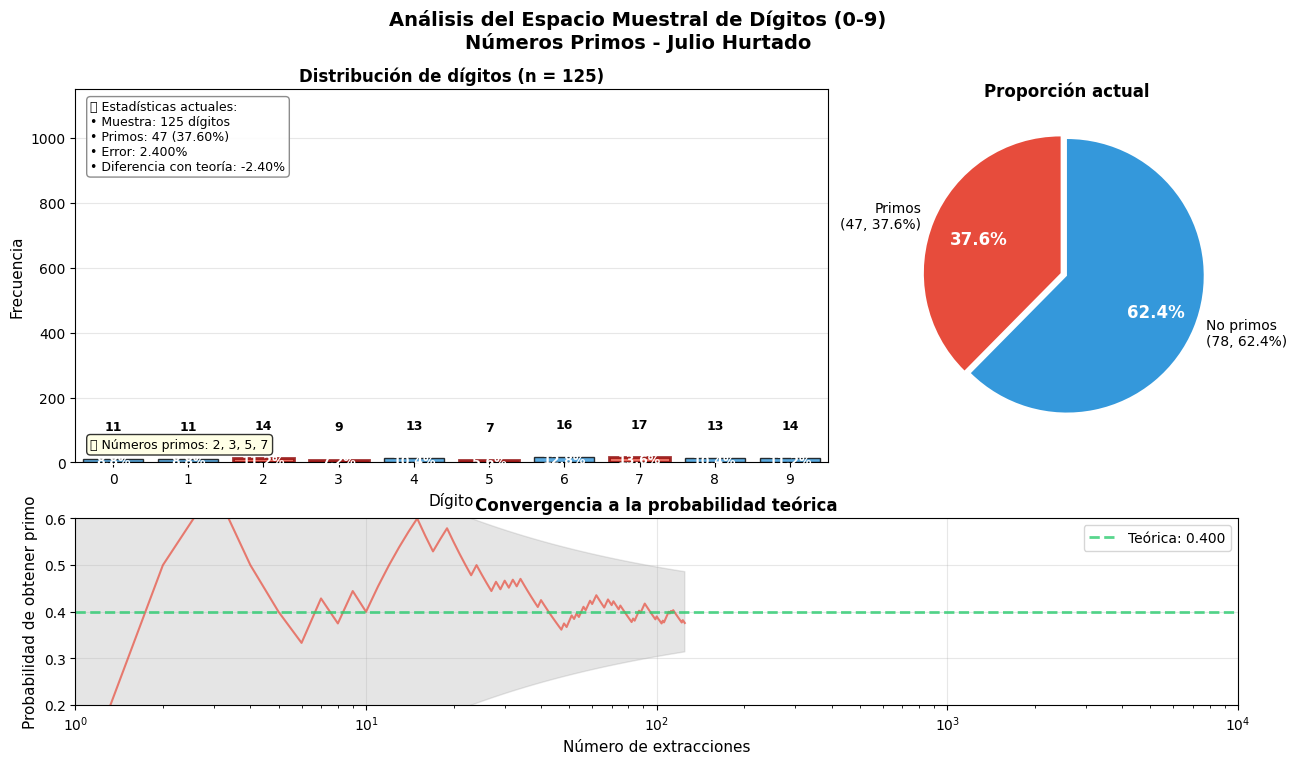

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle, Circle
import matplotlib.patches as mpatches

# Configuración
digitos = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
numeros_primos = np.array([2, 3, 5, 7])
n_total = 10000
frames = 80

# Generar datos
np.random.seed(42)
resultados = np.random.choice(digitos, size=n_total)

# Crear figura con 3 subplots
fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[2, 1])
ax1 = fig.add_subplot(gs[0, :2])  # Distribución de dígitos
ax2 = fig.add_subplot(gs[0, 2])   # Proporción primos vs no primos
ax3 = fig.add_subplot(gs[1, :])   # Convergencia de probabilidad

fig.suptitle("Análisis del Espacio Muestral de Dígitos (0-9)\nNúmeros Primos - Julio Hurtado",
             fontsize=14, fontweight='bold')

# Colores
color_primo = '#E74C3C'
color_no_primo = '#3498DB'
color_teorico = '#2ECC71'

def update(frame):
    # Limpiar ejes
    ax1.clear()
    ax2.clear()
    ax3.clear()

    # Número de extracciones
    n = int((frame + 1) * n_total / frames)
    resultados_actuales = resultados[:n]

    # === GRÁFICO 1: Distribución de frecuencias ===
    frecuencias = [np.sum(resultados_actuales == d) for d in digitos]
    colores_barras = [color_primo if d in numeros_primos else color_no_primo for d in digitos]

    barras = ax1.bar(digitos, frecuencias, color=colores_barras, edgecolor='black', alpha=0.8)

    # Resaltar bordes de números primos
    for i, d in enumerate(digitos):
        if d in numeros_primos:
            barras[i].set_edgecolor('darkred')
            barras[i].set_linewidth(2)

    # Agregar valores sobre barras
    for i, (d, freq) in enumerate(zip(digitos, frecuencias)):
        if freq > 0:
            ax1.text(d, freq + n_total*0.008, str(freq), ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

    # Agregar porcentajes dentro de barras
    for i, (d, freq) in enumerate(zip(digitos, frecuencias)):
        if freq > 0 and n > 0:
            porcentaje = freq / n * 100
            if porcentaje > 5:  # Solo si hay suficiente espacio
                ax1.text(d, freq/2, f"{porcentaje:.1f}%", ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')

    # Configurar gráfico 1
    ax1.set_xlim(-0.5, 9.5)
    ax1.set_ylim(0, max(max(frecuencias), n_total/10) * 1.15)
    ax1.set_xlabel("Dígito", fontsize=11)
    ax1.set_ylabel("Frecuencia", fontsize=11)
    ax1.set_title(f"Distribución de dígitos (n = {n})", fontsize=12, fontweight='bold')
    ax1.set_xticks(digitos)
    ax1.grid(True, alpha=0.3, axis='y')

    # === GRÁFICO 2: Proporción primos vs no primos ===
    n_primos = np.sum(np.isin(resultados_actuales, numeros_primos))
    n_no_primos = n - n_primos

    sizes = [n_primos, n_no_primos]
    colors = [color_primo, color_no_primo]
    labels = [f'Primos\n({n_primos}, {n_primos/n*100:.1f}%)',
              f'No primos\n({n_no_primos}, {n_no_primos/n*100:.1f}%)']
    explode = (0.05, 0)

    wedges, texts, autotexts = ax2.pie(sizes, explode=explode, labels=labels, colors=colors,
                                        autopct='', startangle=90, textprops={'fontsize': 10})

    # Agregar porcentajes manualmente
    for i, (size, color) in enumerate(zip(sizes, colors)):
        porcentaje = size/n*100
        angle = wedges[i].theta2 - (wedges[i].theta2 - wedges[i].theta1)/2
        x = 0.7 * np.cos(np.radians(angle))
        y = 0.7 * np.sin(np.radians(angle))
        ax2.text(x, y, f'{porcentaje:.1f}%', ha='center', va='center',
                fontsize=12, fontweight='bold', color='white')

    ax2.set_title("Proporción actual", fontsize=12, fontweight='bold')

    # === GRÁFICO 3: Convergencia de la probabilidad ===
    es_primo = np.isin(resultados_actuales, numeros_primos)
    prob_acumulada = np.cumsum(es_primo) / np.arange(1, n+1)

    # Muestrear para mejor rendimiento
    paso = max(1, n // 1000)
    indices = np.arange(0, n, paso)
    ax3.plot(indices + 1, prob_acumulada[indices], color=color_primo, linewidth=1.5, alpha=0.7)

    # Línea teórica
    prob_teorica = len(numeros_primos) / len(digitos)
    ax3.axhline(y=prob_teorica, color=color_teorico, linestyle='--', linewidth=2,
                alpha=0.8, label=f'Teórica: {prob_teorica:.3f}')

    # Banda de confianza
    if n > 30:
        z = 1.96
        std_error = np.sqrt(prob_teorica * (1 - prob_teorica) / np.arange(1, n+1))
        ic_sup = prob_teorica + z * std_error
        ic_inf = prob_teorica - z * std_error
        ax3.fill_between(np.arange(1, n+1), ic_inf, ic_sup, alpha=0.2, color='gray')

    # Configurar gráfico 3
    ax3.set_xlim(1, n_total)
    ax3.set_ylim(0.2, 0.6)
    ax3.set_xlabel("Número de extracciones", fontsize=11)
    ax3.set_ylabel("Probabilidad de obtener primo", fontsize=11)
    ax3.set_title("Convergencia a la probabilidad teórica", fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='best', fontsize=10)
    ax3.set_xscale('log')

    # Agregar estadísticas en gráfico 1
    prob_actual = n_primos / n
    error_abs = abs(prob_actual - prob_teorica)

    texto_info = f"📊 Estadísticas actuales:\n"
    texto_info += f"• Muestra: {n} dígitos\n"
    texto_info += f"• Primos: {n_primos} ({prob_actual*100:.2f}%)\n"
    texto_info += f"• Error: {error_abs*100:.3f}%\n"
    texto_info += f"• Diferencia con teoría: {(prob_actual-prob_teorica)*100:+.2f}%"

    ax1.text(0.02, 0.97, texto_info, transform=ax1.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Agregar resumen de números primos
    primos_texto = "🔢 Números primos: " + ", ".join(map(str, numeros_primos))
    ax1.text(0.02, 0.03, primos_texto, transform=ax1.transAxes,
            fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    return barras

# Crear animación
print("🎨 Generando animación completa...")
anim = FuncAnimation(fig, update, frames=frames, interval=40, repeat=True)

# Guardar GIF
anim.save('digitos_espacio_muestral.gif', writer=PillowWriter(fps=20))
print("✅ GIF guardado como 'digitos_espacio_muestral.gif'")

# Mostrar resultados finales
prob_teorica = len(numeros_primos) / len(digitos)
primos_observados = np.sum(np.isin(resultados, numeros_primos))
prob_observada = primos_observados / n_total

print("\n" + "="*60)
print("📊 RESULTADOS FINALES DEL EXPERIMENTO")
print("="*60)
print(f"\n🎲 Espacio muestral: {{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}}")
print(f"🔢 Números primos: {{2, 3, 5, 7}}")
print(f"\n📐 Probabilidad teórica (P(primo)): {prob_teorica:.4f} = {prob_teorica*100:.1f}%")
print(f"📈 Probabilidad experimental (n={n_total}): {prob_observada:.4f} = {prob_observada*100:.2f}%")
print(f"📉 Diferencia: {(prob_observada - prob_teorica)*100:+.3f}%")
print(f"🎯 Error absoluto: {abs(prob_observada - prob_teorica)*100:.3f}%")

print("\n📋 Desglose por dígito:")
print("-" * 40)
for d in digitos:
    freq = np.sum(resultados == d)
    freq_rel = freq / n_total
    tipo = "PRIMO" if d in numeros_primos else "compuesto"
    print(f"Dígito {d} ({tipo:9s}): {freq:5d} veces → {freq_rel*100:5.2f}%")

print("\n✨ Ley de los Grandes Números:")
print(f"   A medida que n aumenta, la frecuencia relativa ({prob_observada*100:.2f}%)")
print(f"   se aproxima a la probabilidad teórica ({prob_teorica*100:.1f}%).")

[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. **




[⬆️ Volver al inicio](#inicio)

<a name="T7"></a>
## **7. **

+

[⬆️ Volver al inicio](#inicio)

<a name="T8"></a>
## **8. **


[⬆️ Volver al inicio](#inicio)

<a name="T9"></a>
## **9. **


[⬆️ Volver al inicio](#inicio)

<a name="T10"></a>
## **10. **




[⬆️ Volver al inicio](#inicio)

<a name="T11"></a>
## **11. **


[⬆️ Volver al inicio](#inicio)

<a name="T12"></a>
## **12. **


[⬆️ Volver al inicio](#inicio)

<a name="T13"></a>
## **13. **


[⬆️ Volver al inicio](#inicio)

<a name="T14"></a>
## **14. **


[⬆️ Volver al inicio](#inicio)

<a name="T1"></a>
## **15. **




[⬆️ Volver al inicio](#inicio)

<a name="T16"></a>
## **16. **


[⬆️ Volver al inicio](#inicio)

<a name="T17"></a>
## **17. **




[⬆️ Volver al inicio](#inicio)

<a name="T18"></a>
## **18. **


[⬆️ Volver al inicio](#inicio)

<a name="T19"></a>
## **19. **


[⬆️ Volver al inicio](#inicio)

<a name="T20"></a>
## **20. **




[⬆️ Volver al inicio](#inicio)

<a name="T21"></a>
## **21. **


[⬆️ Volver al inicio](#inicio)

<a name="T22"></a>
## **22. **


[⬆️ Volver al inicio](#inicio)

<a name="T23"></a>
## **23. **


[⬆️ Volver al inicio](#inicio)

<a name="T24"></a>
## **24. **


[⬆️ Volver al inicio](#inicio)

<a name="T25"></a>
## **25. **




[⬆️ Volver al inicio](#inicio)

<a name="T26"></a>
## **26. **


[⬆️ Volver al inicio](#inicio)

<a name="T27"></a>
## **27. **




[⬆️ Volver al inicio](#inicio)

<a name="T28"></a>
## **28. **


[⬆️ Volver al inicio](#inicio)

<a name="T29"></a>
## **29. **


[⬆️ Volver al inicio](#inicio)

<a name="T30"></a>
## **30. **




[⬆️ Volver al inicio](#inicio)


## **ULTIMO**
[⬆️ Volver al ULTIMO](#ULTIMO)


<a name="ULTIMO"></a>

[⬆️ Volver al inicio](#inicio)

ULTIMO